<a href="https://colab.research.google.com/github/Fidyaayu/Project-3_Bean-Disease-Classification/blob/main/Bean_Diases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYEK CNN - BEAN DISEASE**

## IMPORT LIBRARY

In [ ]:
# Library dasar
import os
import numpy as np
import pandas as pd
!pip install split-folders
import splitfolders

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Pengolahan gambar
from PIL import Image

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Evaluasi model
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Supaya hasil random konsisten
np.random.seed(42)
tf.random.set_seed(42)

print("Library berhasil diimport")

Library berhasil diimport


## LOAD DATASET

In [ ]:
dataset_path = "/content/drive/MyDrive/MAGANG/juni minggu 1_proyek 5/Bean_Dataset"
output_path = "/content/drive/MyDrive/MAGANG/juni minggu 1_proyek 5/Bean_Split"

# Pastikan direktori output ada
os.makedirs(output_path, exist_ok=True)

# Pisah dataset jadi train/val/test (70/15/15)
splitfolders.ratio(
    dataset_path,
    output=output_path,
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

print("Split selesai!")
print(os.listdir(output_path))


Copying files: 0 files [00:00, ? files/s]
Copying files: 3 files [00:00, 26.49 files/s]
Copying files: 6 files [00:00,  5.97 files/s]
Copying files: 12 files [00:00, 13.68 files/s]
Copying files: 19 files [00:01, 22.64 files/s]
Copying files: 27 files [00:01, 32.90 files/s]
Copying files: 33 files [00:01, 38.42 files/s]
Copying files: 39 files [00:01, 43.16 files/s]
Copying files: 45 files [00:01, 47.27 files/s]
Copying files: 51 files [00:01, 49.40 files/s]
Copying files: 57 files [00:01, 51.77 files/s]
Copying files: 63 files [00:01, 52.57 files/s]
Copying files: 70 files [00:01, 53.79 files/s]
Copying files: 77 files [00:02, 56.58 files/s]
Copying files: 83 files [00:02, 57.19 files/s]
Copying files: 90 files [00:02, 59.58 files/s]
Copying files: 97 files [00:02, 58.58 files/s]
Copying files: 103 files [00:02, 57.90 files/s]
Copying files: 109 files [00:02, 57.75 files/s]
Copying files: 115 files [00:02, 55.88 files/s]
Copying files: 122 files [00:02, 58.26 files/s]
Copying files: 

Split selesai!
['train', 'val', 'test']


## Exploratory Data Analysis (EDA)

### Menampilkan Nama Kelas

In [ ]:
classes = os.listdir(dataset_path)

print("Jumlah kelas :", len(classes))
print("Nama kelas :", classes)

Jumlah kelas : 3
Nama kelas : ['healthy', 'angular_leaf_spot', 'bean_rust']


### Menghitung Jumlah Gambar per Kelas

In [ ]:
image_count = []

for kelas in classes:
    folder_path = os.path.join(dataset_path, kelas)
    jumlah = len(os.listdir(folder_path))
    image_count.append(jumlah)

    print(f"{kelas} : {jumlah} gambar")

healthy : 330 gambar
angular_leaf_spot : 330 gambar
bean_rust : 330 gambar


### Visualisasi Distribusi Data

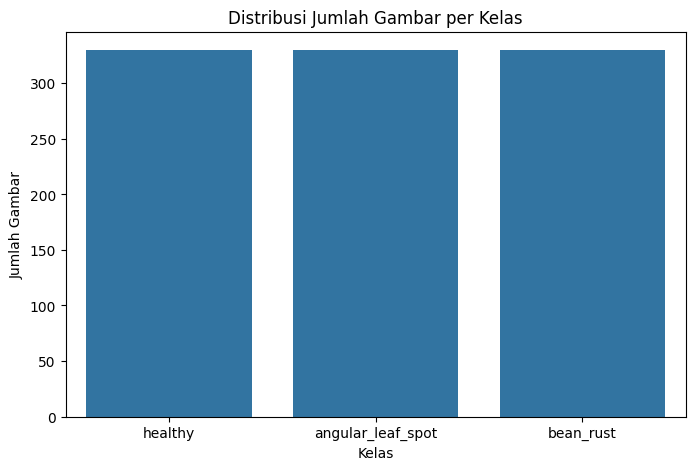

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(x=classes, y=image_count)

plt.title("Distribusi Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")

plt.show()

### Menampilkan Contoh Gambar Tiap Kelas

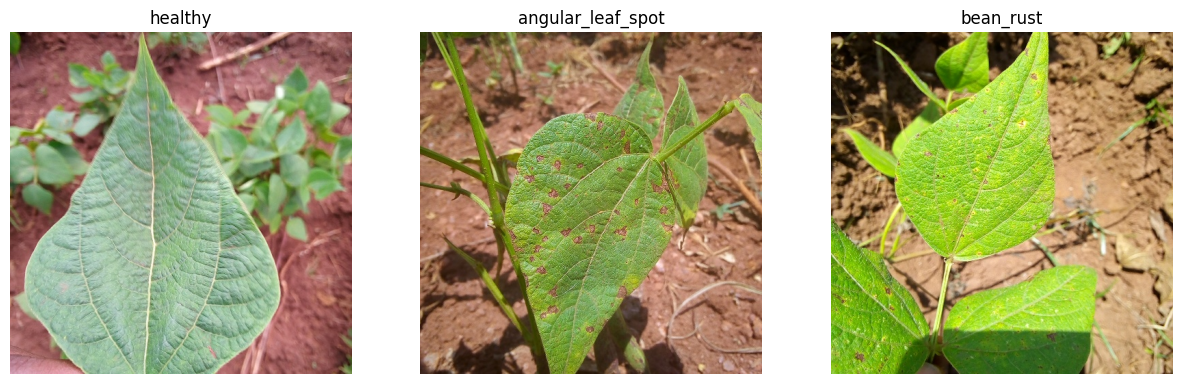

In [ ]:
plt.figure(figsize=(15, 5))

for i, kelas in enumerate(classes):
    folder_path = os.path.join(dataset_path, kelas)
    image_name = os.listdir(folder_path)[0]
    image_path = os.path.join(folder_path, image_name)
    img = Image.open(image_path)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(kelas)
    plt.axis('off')

plt.show()

### Menampilkan Ukuran dan Shape Gambar

In [ ]:
sample_class = classes[0]
sample_folder = os.path.join(dataset_path, sample_class)
sample_image = os.listdir(sample_folder)[0]
sample_path = os.path.join(sample_folder, sample_image)

img = Image.open(sample_path)
print("Ukuran gambar :", img.size)

img_array = np.array(img)
print("Shape gambar :", img_array.shape)

Ukuran gambar : (500, 500)
Shape gambar : (500, 500, 3)


## PREPOCESSING DATA

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)
# Hapus validation_split=0.2 karena sudah dipisah manual

In [ ]:
# Data Train
train_generator = train_datagen.flow_from_directory(
    os.path.join(output_path, 'train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# Data Validation
validation_generator = val_test_datagen.flow_from_directory(
    os.path.join(output_path, 'val'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Data Test (benar-benar terpisah)
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(output_path, 'test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("Jumlah data training   :", train_generator.samples)
print("Jumlah data validation :", validation_generator.samples)
print("Jumlah data test       :", test_generator.samples)

Found 690 images belonging to 3 classes.
Found 147 images belonging to 3 classes.
Found 153 images belonging to 3 classes.
Jumlah data training   : 690
Jumlah data validation : 147
Jumlah data test       : 153


## **IMPLEMENTASI MODEL CNN**

## Membuat Model CNN

In [ ]:
model = Sequential()

# CONVOLUTION LAYER 1
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(224,224,3)
))

# MAX POOLING 1
model.add(MaxPooling2D(pool_size=(2,2)))

# CONVOLUTION LAYER 2
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

# MAX POOLING 2
model.add(MaxPooling2D(pool_size=(2,2)))

# CONVOLUTION LAYER 2
model.add(Conv2D(
    128,
     (3,3),
    activation='relu'
    ))

# MAX POOLING 2
model.add(MaxPooling2D(2,2))

# FLATTEN
model.add(Flatten())

# FULLY CONNECTED LAYER
model.add(Dense(128, activation='relu'))

# DROPOUT
model.add(Dropout(0.5))

# OUTPUT LAYER
model.add(Dense(len(classes), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Arsitektur Model

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## Compile dan Training Model

### Compile Model

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001    # tambahkan ini, supaya tidak berhenti di perubahan kecil
)

### Training Model

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 103s 4s/step - accuracy: 0.3928 - loss: 1.0919 - val_accuracy: 0.5442 - val_loss: 1.0294
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 135s 4s/step - accuracy: 0.5319 - loss: 0.9861 - val_accuracy: 0.5714 - val_loss: 0.9540
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.6130 - loss: 0.9061 - val_accuracy: 0.6599 - val_loss: 0.8714
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step - accuracy: 0.6232 - loss: 0.8547 - val_accuracy: 0.5918 - val_loss: 0.8534
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.6768 - loss: 0.7905 - val_accuracy: 0.6259 - val_loss: 0.8171
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step - accuracy: 0.6696 - loss: 0.7699 - val_accuracy: 0.5986 - val_loss: 0.8607
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.7130 - loss: 0.7287 - val_accuracy: 0.6395 - val_loss: 0.8376
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.7174 - loss: 0.7001 - val_accuracy: 0.6735 - val_los

### Menampilkan Hasil Training

In [ ]:
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

train_loss = history.history['loss']
val_loss = history.history['val_loss']

print("Training Accuracy Terakhir :", train_acc[-1])
print("Validation Accuracy Terakhir :", val_acc[-1])

print("Training Loss Terakhir :", train_loss[-1])
print("Validation Loss Terakhir :", val_loss[-1])

Training Accuracy Terakhir : 0.7492753863334656
Validation Accuracy Terakhir : 0.6734693646430969
Training Loss Terakhir : 0.6184736490249634
Validation Loss Terakhir : 0.7378624081611633


## Visualisasi Hasil Training

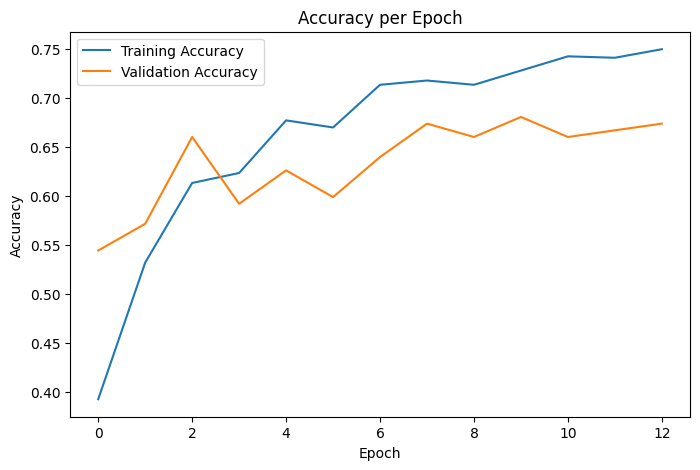

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

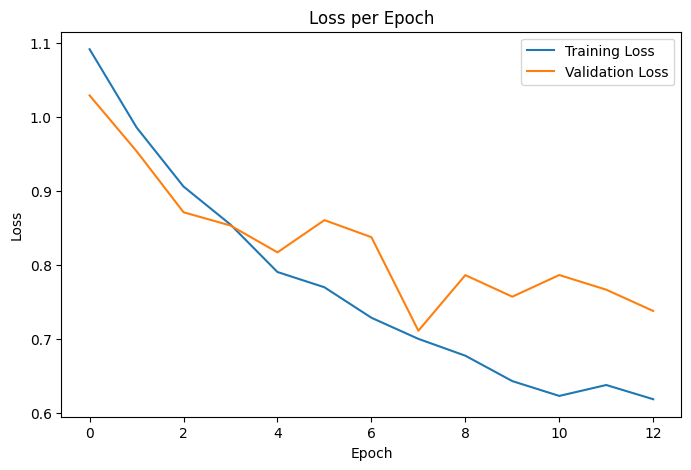

In [ ]:
# Grafik Loss
plt.figure(figsize=(8,5))

plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

## Evaluasi Model

In [ ]:
# Evaluasi Accuracy
loss, accuracy = model.evaluate(test_generator)
print("Test Accuracy :", accuracy)
print("Test Loss     :", loss)

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6797 - loss: 0.7529
Test Accuracy : 0.6797385811805725
Test Loss     : 0.7529090642929077


In [ ]:
#Prediksi Test Set
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step


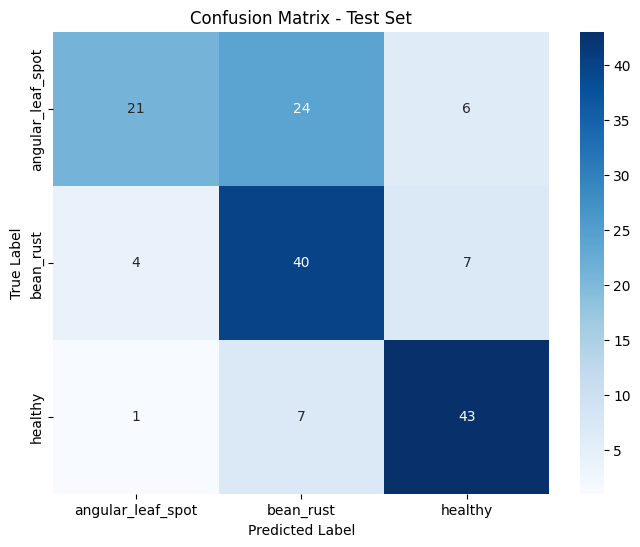

In [ ]:
# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.show()

In [ ]:
# Classification Report
report = classification_report(true_classes, predicted_classes,
                               target_names=class_labels)
print(report)

                   precision    recall  f1-score   support

angular_leaf_spot       0.81      0.41      0.55        51
        bean_rust       0.56      0.78      0.66        51
          healthy       0.77      0.84      0.80        51

         accuracy                           0.68       153
        macro avg       0.71      0.68      0.67       153
     weighted avg       0.71      0.68      0.67       153



## Prediksi Gambar

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 831ms/step


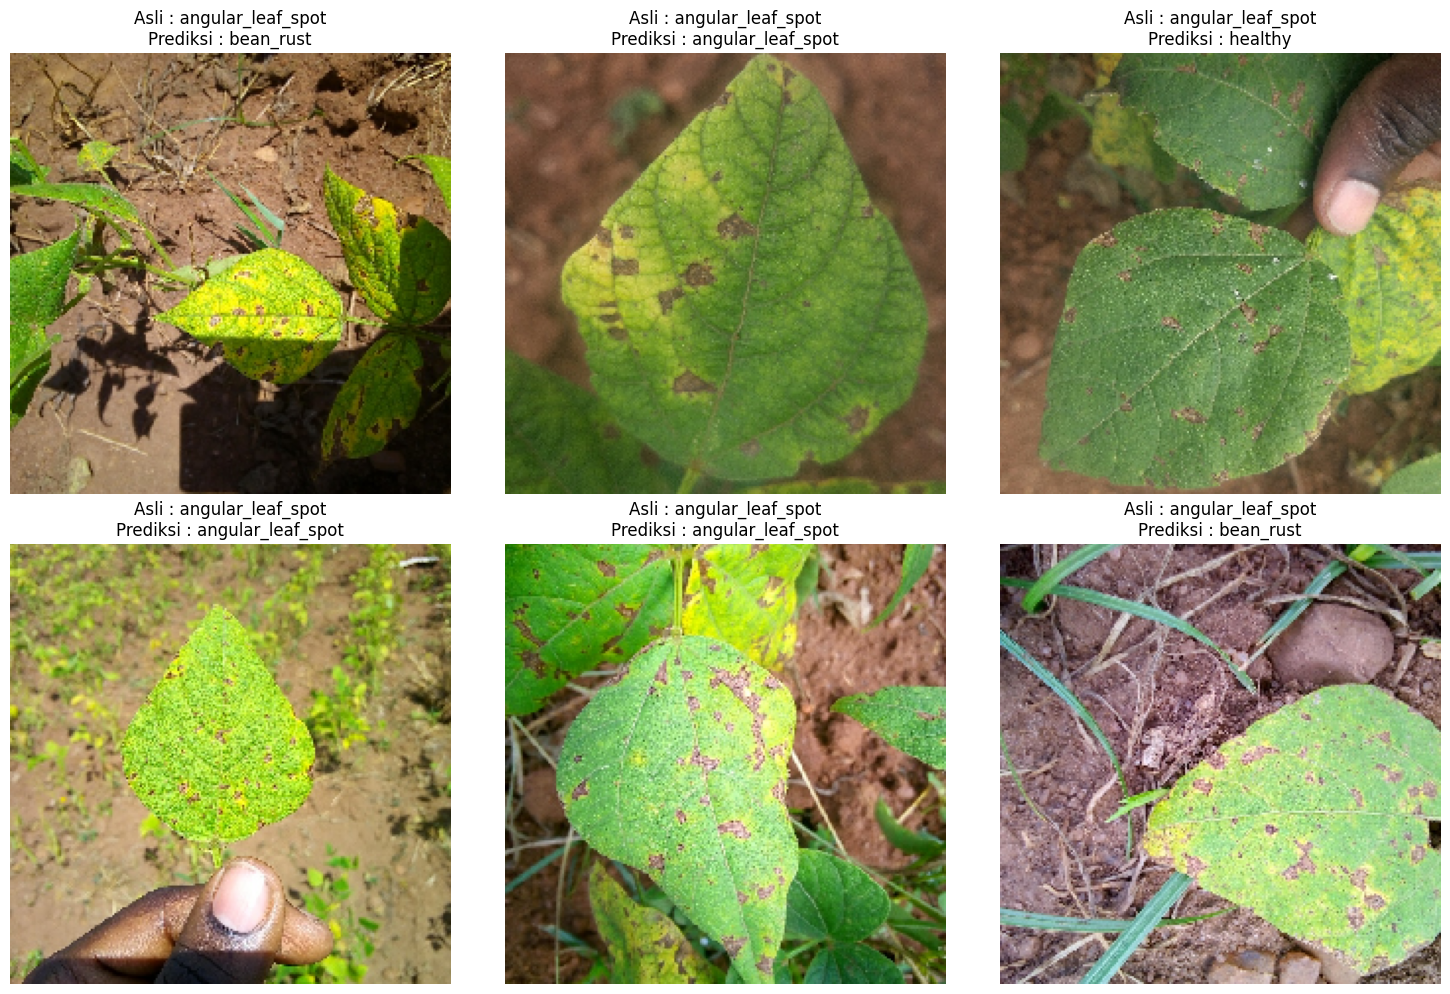

In [ ]:
plt.figure(figsize=(15, 10))

images, labels = next(test_generator)
preds = model.predict(images)

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    true_label = class_labels[np.argmax(labels[i])]
    pred_label = class_labels[np.argmax(preds[i])]
    plt.title(f"Asli : {true_label}\nPrediksi : {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()